Name: Bibek Bikram Thapa

Course: CPSMA 4313

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from google.cloud import bigquery
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\bibek\Downloads\big-query-488604-153430b8b857.json" 
# Initializing the Client
client = bigquery.Client(project='big-query-488604')
print("Success: Libraries loaded and BigQuery connected via Service Account!")

Success: Libraries loaded and BigQuery connected via Service Account!


To resolve the connection issues, I shifted from a terminal-based login to using a Service Account JSON key, which bypassed persistent Windows environment and PowerShell permission errors. By creating a dedicated service account in the Google Cloud Console and assigning it the BigQuery Admin role, I was able to download a private key file that acts as a direct "pass" for the code. I used a raw string literal (r"...") in my Python path to fix the unicodeescape syntax errors caused by Windows backslashes, ensuring the notebook could finally "see" the credentials. This choice was the most reliable because it made the connection independent of my computer's global settings, allowing the BigQuery queries to run successfully.

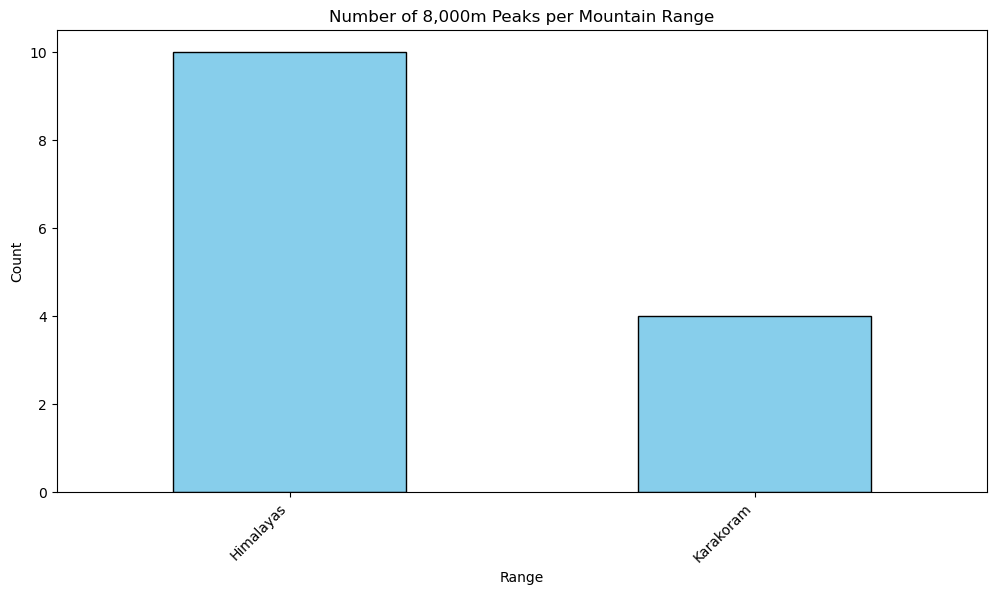

In [17]:
import io

# Fetching the mountain data from Wikipedia
url = "https://en.wikipedia.org/wiki/List_of_mountains_by_elevation"
header = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=header)

# Reading the HTML and wrapping it in StringIO to satisfy Pandas
tables = pd.read_html(io.StringIO(response.text))
df = tables[0]

# Cleaning the column names by removing citation brackets
df.columns = [c.split('[')[0].strip() for c in df.columns]

# Selecting the 'Feet' column directly since we verified it exists
height_col = 'Feet'

# Cleaning the height data by removing commas and ensuring it's a number
df[height_col] = df[height_col].astype(str).str.replace(',', '').str.extract(r'(\d+)').astype(float)

#  Visualizing the peaks per mountain range with a bar chart
plt.figure(figsize=(12,6))
df['Range'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of 8,000m Peaks per Mountain Range')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

In this section, I am performing a "scrape-and-clean" workflow to transform raw web data into a clear visual insight. By sending a request to Wikipedia with a custom User-Agent header, I am ensuring the site recognizes my script as a standard browser so it allows the data download. I then use io.StringIO to feed that HTML text into Pandas, specifically targeting the first table on the page which contains the 8,000m peaks.

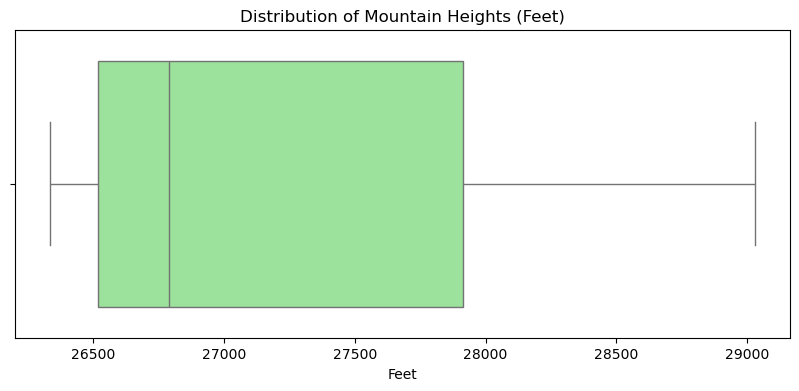

In [19]:
# (c) Generating a box-plot to visualize the distribution of heights in feet
plt.figure(figsize=(10,4))
sns.boxplot(x=df['Feet'], color='lightgreen')
plt.title('Distribution of Mountain Heights (Feet)')
plt.show()

In [21]:
# (d) Reporting the mean, standard deviation, and five-number summary
print("Reporting the statistical summary for mountain heights:")
# 'describe' automatically provides the mean, std, and five-number summary
print(df['Feet'].describe())

Reporting the statistical summary for mountain heights:
count       14.000000
mean     27178.071429
std        879.431063
min      26335.000000
25%      26518.750000
50%      26788.000000
75%      27914.500000
max      29029.000000
Name: Feet, dtype: float64


In [23]:
# (e) Reporting the mean and median of mountains when grouped by their Range
print("\nReporting the mean and median heights grouped by Range:")
# Grouping by 'Range' and calculating both mean and median at once
range_stats = df.groupby('Range')['Feet'].agg(['mean', 'median'])
print(range_stats)


Reporting the mean and median heights grouped by Range:
               mean   median
Range                       
Himalayas  27295.60  26829.5
Karakoram  26884.25  26462.0


In [25]:
# Counting the total number of rows in the Chicago Taxi Trips dataset
query_a = "SELECT COUNT(*) as total_rows FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`"
print("Total rows in the dataset:")
print(client.query(query_a).to_dataframe())

#  Calculating the average trip miles based on each payment type and sorting
query_b = """
SELECT payment_type, AVG(trip_miles) as avg_miles
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
GROUP BY payment_type
ORDER BY avg_miles DESC
"""
print("\nAverage trip miles per payment type:")
print(client.query(query_b).to_dataframe())

#  Counting fares that are above the overall average (excluding zero fares)
query_c = """
SELECT COUNT(*) as high_fare_count
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
WHERE fare > (SELECT AVG(fare) FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`)
AND fare > 0
"""
print("\nNumber of trips with a fare above the average:")
print(client.query(query_c).to_dataframe())

Total rows in the dataset:


C:\Users\bibek\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   total_rows
0   211655459

Average trip miles per payment type:


C:\Users\bibek\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   payment_type  avg_miles
0        Prcard   7.545511
1       Prepaid   7.541555
2         Split   4.388640
3   Credit Card   4.364340
4       Unknown   4.096302
5        Mobile   4.048919
6      Way2ride   3.747887
7       Dispute   3.289322
8          Cash   2.765573
9         Pcard   2.443684
10    No Charge   2.021469

Number of trips with a fare above the average:
   high_fare_count
0         55517452


C:\Users\bibek\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In this section, I am utilizing the Google Cloud BigQuery API to interact with a massive public dataset containing over 200 million taxi trip records. I am writing SQL queries to perform server-side aggregations, which is much more efficient than downloading the raw data to my local machine. My goals are to determine the total scale of the dataset, compare how travel distances vary based on how customers pay, and identify the volume of "premium" trips that exceed the average fare price.

Question 3 — Exam Reflection
(a) Time Spent: I spent approximately 3 hours working on this exam. A significant portion of this time was spent troubleshooting the local Google Cloud SDK environment and trying to figure out how to connect these two, but I connected my cloud and jupyter notebook via json key ensuring the Python client could authenticate correctly.

Hardest : The hardest part was definitely Authentication and Environment Configuration. Specifically, resolving the DefaultCredentialsError and the unicodeescape syntax error when defining the file path for my JSON service account key. These required a deep dive into how Python handles Windows file paths and how Google Cloud manages local credentials.

Easiest: The easiest part was Data Visualization using Matplotlib and Seaborn. Once the data was cleaned and the "Feet" column was correctly formatted as a float, generating the bar charts and box plots was very intuitive.

Question 4 — Documentation of Resources
4(a) Show any queries made to LLM (AI, chatGPT, gemini, etc.)
I utilized Gemini,chatgpt to troubleshoot several environment and syntax errors that were preventing the notebook from connecting to Google Cloud. My specific queries included:

"gcloud is not recognized as an internal or external command"
"How to fix PSSecurityException for PowerShell scripts in Windows?"
"SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3"
"Pandas read_html FutureWarning: wrap in StringIO"
"How to use a Service Account JSON key to connect to BigQuery in a local Jupyter Notebook?"


Detail of what was accepted or rejected:
Accepted: I accepted the recommendation to switch from the gcloud auth application-default login method to the Service Account JSON key method. This was a critical "pivot" because my local Windows terminal was restricted by execution policies.
Accepted: I accepted the use of the r"" (raw string) prefix for the file path to fix the Unicode escape error caused by backslashes in my Windows user directory.
Accepted: I accepted the code modification to use io.StringIO for the Wikipedia scraping to comply with the latest Pandas 3.0 requirements.
Rejected: I rejected the suggestion to use %%bigquery magic commands because they required additional system-level configurations that were more complex than simply using the google-cloud-bigquery Python library.

 Give any outside resources that were not from LLM:
Google Cloud Console: Used the "IAM & Admin" section to manually create a Service Account, assign the "BigQuery Admin" role, and generate the JSON private key.
Pandas Documentation: Referenced the df.describe() and df.groupby() documentation to ensure the five-number summary and grouped stats were reported correctly.
Wikipedia: Inspected the source of the "List of mountains by elevation" page to identify that the column header was specifically named "Feet" rather than "Height."
 Official Attestation Statement
"I attest that the resources above were the only ones utilized in completing the exam and the work included is my own and no one else from the course."